In [1]:
# ================================
# Import libraries
# ================================
# Standard library
import glob
import json
import os
import shutil
from pathlib import Path

# Third-party library
import numpy as np
from PIL import Image
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_aws import BedrockEmbeddings
import boto3

print("✅ Environment ready")
print(os.getcwd())           # current directory
print(os.access(os.getcwd(), os.W_OK))  # is it writable?

✅ Environment ready
/Users/anirudh/Desktop/Courseera/IBM-RAG and agentic AI/RAG and Agentic AI Capstone Project
True


In [2]:
# ================================
# Verify vector database
# ================================

DB_DIR = str((Path.cwd() / "chroma_multimodal").resolve())

if not os.path.isdir(DB_DIR):
    raise RuntimeError(
        f"Vector database directory not found: '{DB_DIR}'. "
        "Please run Lesson 1 (Multimodal Vector Index Construction) first."
    )

article_db = Chroma(
    collection_name="restaurant_articles",
    persist_directory=DB_DIR,
)

image_db = Chroma(
    collection_name="food_images",
    persist_directory=DB_DIR,
)

n_articles = article_db._collection.count()
n_images = image_db._collection.count()

if n_articles <= 0 or n_images <= 0:
    raise RuntimeError(
        "One or more collections are empty. Please rerun Lesson 1 to rebuild the index."
    )

print(f"✅ Article vectors: {n_articles}")
print(f"✅ Image vectors:   {n_images}")


/var/folders/kv/9b0l8lv56tsc3yvfy9l9nq180000gn/T/ipykernel_40180/3546203431.py:13: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  article_db = Chroma(


✅ Article vectors: 210
✅ Image vectors:   109


In [3]:
# ================================
# Initialize embedding models
# ================================
import base64
import numpy as np
from langchain_aws import BedrockEmbeddings
import boto3

# ---- Text embedding model (1024-d) ----
text_embedder = BedrockEmbeddings(
    model_id="amazon.titan-embed-text-v2:0",
    region_name="us-east-1",
    model_kwargs={"normalize": True}  # cosine-ready
)

def embed_texts(texts, batch_size=64):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        batch_embeddings = text_embedder.embed_documents(batch)
        embeddings.extend(batch_embeddings)
    return np.array(embeddings, dtype=np.float32)

print("✅ Text embedder ready")

bedrock_client = boto3.client(
    service_name="bedrock-runtime",
    region_name="us-east-1"
)

def embed_images(paths, batch_size=16):
    embeddings = []
    for i in range(0, len(paths), batch_size):
        batch = paths[i:i+batch_size]
        for image_path in batch:
            # Encode image to base64
            with open(image_path, 'rb') as f:
                image_data = base64.b64encode(f.read()).decode('utf-8')

            # Call Titan Multimodal directly via boto3
            body = json.dumps({
                "inputImage": image_data,  # base64 encoded image
                "embeddingConfig": {
                    "outputEmbeddingLength": 1024
                }
            })

            response = bedrock_client.invoke_model(
                modelId="amazon.titan-embed-image-v1",
                body=body,
                contentType="application/json",
                accept="application/json"
            )

            result = json.loads(response['body'].read())
            embedding = result['embedding']

            # Normalize - cosine ready
            vector = np.array(embedding, dtype=np.float32)
            vector = vector / np.linalg.norm(vector)
            embeddings.append(vector)

    return np.array(embeddings, dtype=np.float32)

print("✅ Image embedder ready")

✅ Text embedder ready
✅ Image embedder ready


In [4]:
# ================================
# Retrieval utilities
# ================================

# Chroma returns lists-of-lists; unwrap the first query.
def _unwrap(res: dict):  
    ids = res.get("ids", [[]])[0]
    docs = res.get("documents", [[]])[0]
    metas = res.get("metadatas", [[]])[0]
    dists = res.get("distances", [[]])[0]
    return ids, docs, metas, dists

def print_hits(ids, docs, metas, dists, title: str, max_chars: int = 180):
    print(f"\n=== {title} ===")
    for i in range(len(ids)):
        meta = metas[i] if i < len(metas) else {}
        dist = float(dists[i]) if i < len(dists) else None

        snippet = (docs[i] or "").replace("\n", " ").strip()
        if len(snippet) > max_chars:
            snippet = snippet[:max_chars].rstrip() + "..."

        # compact metadata view
        cuisine = meta.get("cuisine", "N/A") if isinstance(meta, dict) else "N/A"
        location = meta.get("location", "N/A") if isinstance(meta, dict) else "N/A"
        doc_id = meta.get("doc_id", "N/A") if isinstance(meta, dict) else "N/A"
        source = meta.get("source", "N/A") if isinstance(meta, dict) else "N/A"

        print(f"[{i+1}] id={doc_id} | cuisine={cuisine} | location={location} | source={source} | distance={dist:.4f}")
        print(f"{snippet}")


In [5]:
# ================================
# Article retrieval
# ================================

# Similarity retrieval over restaurant articles with optional metadata filtering.
def retrieve_articles(query: str, k: int = 5, where: dict | None = None):

    q_vec = embed_texts([query])[0]  # 384-d, cosine-ready

    res = article_db._collection.query(
        query_embeddings=[q_vec.tolist()],
        n_results=k,
        where=where,
        include=["documents", "metadatas", "distances"],
    )
    return _unwrap(res)

print("✅ Article retrieval ready")


✅ Article retrieval ready


In [6]:
# ================================
# Image retrieval
# ================================

# Similarity retrieval over food images using an image query.
def retrieve_images_by_image(query_image_path: str, k: int = 5, where: dict | None = None):

    q_vec = embed_images([query_image_path])[0]  # 512-d, cosine-ready

    res = image_db._collection.query(
        query_embeddings=[q_vec.tolist()],
        n_results=k,
        where=where,
        include=["documents", "metadatas", "distances"],
    )
    return _unwrap(res)

print("✅ Image retrieval ready")


✅ Image retrieval ready


In [7]:
# ================================
# Demo 1 — Article similarity search (no filter)
# ================================

q = "cozy restaurant with noodles and warm atmosphere"

ids, docs, metas, dists = retrieve_articles(q, k=5, where=None)
print_hits(ids, docs, metas, dists, title="Demo 1 — Article similarity search (no filter)")

print("✅ Demo 1 complete")



=== Demo 1 — Article similarity search (no filter) ===
[1] id=rest_73 | cuisine=Hand-Pulled Noodle | location=San Gabriel | source=restaurant | distance=1.2248
Restaurant: The Noodle Nest Cuisine: Hand-Pulled Noodle Location: San Gabriel
[2] id=rest_49 | cuisine=instant noodle gourmet bowls, pineapple buns | location=Monterey Park | source=restaurant | distance=1.2437
Restaurant: The Neon Noodle Bar Cuisine: instant noodle gourmet bowls, pineapple buns Location: Monterey Park
[3] id=rest_150 | cuisine=Taiwanese | location=Irvine | source=restaurant | distance=1.2527
Restaurant: The Silk Noodle Cuisine: Taiwanese Location: Irvine
[4] id=rest_7 | cuisine=Sichuan street food | location=San Gabriel Valley | source=restaurant | distance=1.2721
Restaurant: The Neon Noodle Bar Cuisine: Sichuan street food Location: San Gabriel Valley
[5] id=rest_164 | cuisine=Japanese-Vietnamese | location=Anaheim | source=restaurant | distance=1.2747
Restaurant: The Neon Noodle Cuisine: Japanese-Vietnamese 

In [8]:
# ================================
# Demo 2 — Article similarity search + metadata filter
# ================================

q = "handmade pasta and romantic dinner"

# ---- metadata constraint (must exist in your dataset) ----
where_filter = {"location": "Pasadena"}  # adjust if needed

ids, docs, metas, dists = retrieve_articles(q, k=5, where=where_filter)

if len(ids) == 0:
    print("⚠️ No results found with current filter.")
else:
    print_hits(ids, docs, metas, dists, title="Demo 2 — Article similarity search + metadata filter")
    
print("✅ Demo 2 complete")



=== Demo 2 — Article similarity search + metadata filter ===
[1] id=rest_160 | cuisine=Victorian excess | location=Pasadena | source=restaurant | distance=1.5590
Restaurant: The Gilded Rose Cuisine: Victorian excess Location: Pasadena
[2] id=rest_206 | cuisine=organic farm-to-table | location=Pasadena | source=restaurant | distance=1.5900
Restaurant: Maple & Moss Cuisine: organic farm-to-table Location: Pasadena
[3] id=rest_6 | cuisine=French-Mediterranean | location=Pasadena | source=restaurant | distance=1.6126
Restaurant: Velvet & Vine Cuisine: French-Mediterranean Location: Pasadena
[4] id=rest_61 | cuisine=Plant-Based | location=Pasadena | source=restaurant | distance=1.6277
Restaurant: Urban Harvest Cuisine: Plant-Based Location: Pasadena
[5] id=rest_19 | cuisine=Modern Indian | location=Pasadena | source=restaurant | distance=1.6441
Restaurant: The Copper Pot Cuisine: Modern Indian Location: Pasadena
✅ Demo 2 complete


Query image: recipe_images/synthetic_recipe_images/recipe1.png


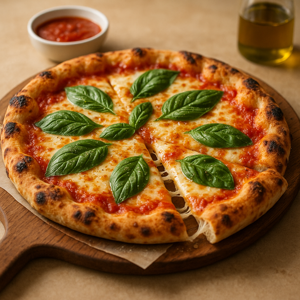


=== Demo 3 — Image similarity search (image→image) ===
[1] id=img_0 | cuisine=Italian | location=N/A | source=recipe_image | distance=0.0000
Classic Margherita Pizza
[2] id=img_38 | cuisine=Italian | location=N/A | source=recipe_image | distance=0.9063
Caprese Salad
[3] id=img_82 | cuisine=Italian | location=N/A | source=recipe_image | distance=0.9134
Pesto Pasta with Sun-Dried Tomatoes
[4] id=img_25 | cuisine=Italian | location=N/A | source=recipe_image | distance=0.9745
Lemon Garlic Shrimp Pasta
[5] id=img_4 | cuisine=Italian | location=N/A | source=recipe_image | distance=0.9894
Spaghetti Aglio e Olio

=== Demo 3 — Restaurant similarity search ===
[1] id=rest_208 | cuisine=Italian | location=Silver Lake | source=restaurant | distance=1.5551
Restaurant: The Pasta Project Cuisine: Italian Location: Silver Lake
[2] id=rest_113 | cuisine=Italian | location=Sherman Oaks | source=restaurant | distance=1.5678
Restaurant: Ventura Velvet Cuisine: Italian Location: Sherman Oaks
[3] id=rest_7

In [15]:
# ================================
# Demo 3 — Image similarity search (image→image) + Restaurant results
# ================================
meta_all = image_db._collection.get(include=["metadatas"])["metadatas"]
QUERY_INDEX = 0

query_img = meta_all[QUERY_INDEX]["image_path"]

# Display query image
print(f"Query image: {query_img}")
img = Image.open(query_img)
img.thumbnail((300, 300))
display(img)

# Image similarity search
where_image = {"cuisine": "Italian"}
ids, docs, metas, dist = retrieve_images_by_image(
    query_img, k=5, where=where_image
)
print_hits(ids, docs, metas, dist, title="Demo 3 — Image similarity search (image→image)")

# Restaurant similarity search using recipe name
query_text = docs[0]  # use top image result as query text
ids, docs, metas, dist = retrieve_articles(
    query_text,   # text query
    k=5,
    where={"cuisine": "Italian"}  # filter by cuisine
)
print_hits(ids, docs, metas, dist, title="Demo 3 — Restaurant similarity search")

print("✅ Demo 3 complete")
print("🎉 Similarity Retrieval with Metadata Filtering COMPLETE")